# Image Processing Lab 02

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Đọc ảnh

(np.float64(-0.5), np.float64(1199.5), np.float64(674.5), np.float64(-0.5))

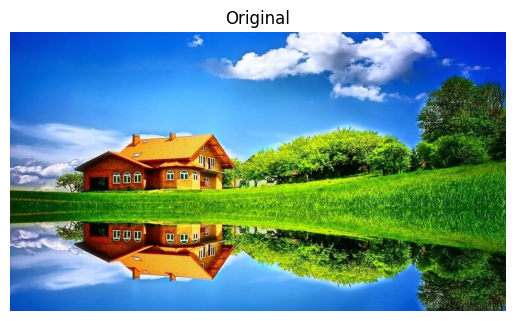

In [4]:
img = cv2.imread("lab02.jpg")  # đổi đường dẫn
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = img.astype(np.int16)

plt.imshow(img)
plt.title("Original")
plt.axis('off')

## I. Toán tử điểm ảnh

### I.1 Thay đổi độ sáng

(np.float64(-0.5), np.float64(1199.5), np.float64(674.5), np.float64(-0.5))

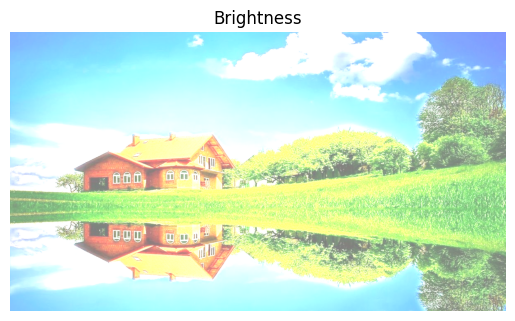

In [5]:
#Thay đổi độ sáng: Tăng hoặc giảm độ sáng của toàn bộ hình ảnh bằng cách cộng hoặc trừ một giá trị cố định cho mỗi điểm ảnh.
def change_brightness(image, value):
    return np.clip(image + value, 0, 255).astype(np.uint8)

bright = change_brightness(img, 125)

plt.imshow(bright)
plt.title("Brightness")
plt.axis('off')

### I.2 Thay đổi độ tương phản

(np.float64(-0.5), np.float64(1199.5), np.float64(674.5), np.float64(-0.5))

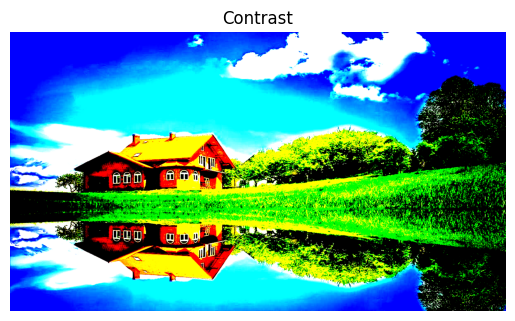

In [6]:
#Thay đổi độ tương phản: Tăng hoặc giảm độ tương phản bằng cách nhân mỗi điểm ảnh với một hằng số.
def change_contrast(image, alpha):
    return np.clip((image - 128) * alpha + 128, 0, 255).astype(np.uint8)

contrast = change_contrast(img, 6)

plt.imshow(contrast)
plt.title("Contrast")
plt.axis('off')

### I.3 Âm bản

(np.float64(-0.5), np.float64(1199.5), np.float64(674.5), np.float64(-0.5))

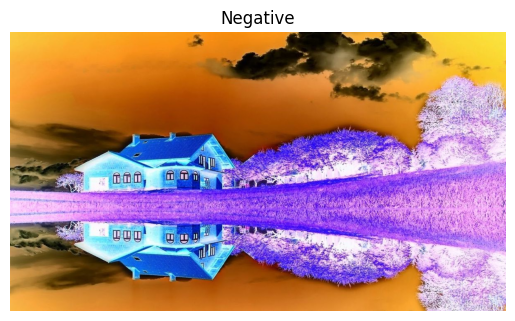

In [7]:
#Tạo ảnh âm bản: Tạo ảnh âm bản bằng cách trừ mỗi điểm ảnh từ 255.
def negative(image):
    return 255 - image

neg = negative(img)

plt.imshow(neg)
plt.title("Negative")
plt.axis('off')

### I.4 Cắt ngưỡng

(np.float64(-0.5), np.float64(1199.5), np.float64(674.5), np.float64(-0.5))

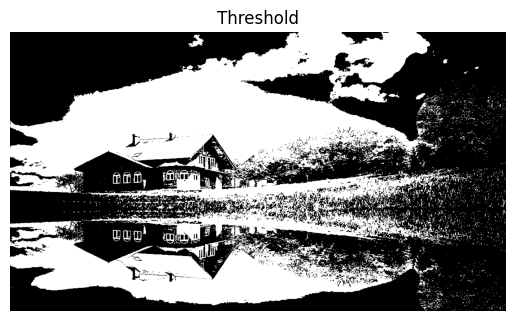

In [8]:
img = np.clip(img, 0, 255).astype(np.uint8)
def threshold(image, thresh):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    _, binary = cv2.threshold(gray, thresh, 255, cv2.THRESH_BINARY)
    return binary

thresh = threshold(img, 127)

plt.imshow(thresh, cmap='gray')
plt.title("Threshold")
plt.axis('off')

## II. Lọc tuyến tính

### II.1 Lọc trung bình

(np.float64(-0.5), np.float64(1199.5), np.float64(674.5), np.float64(-0.5))

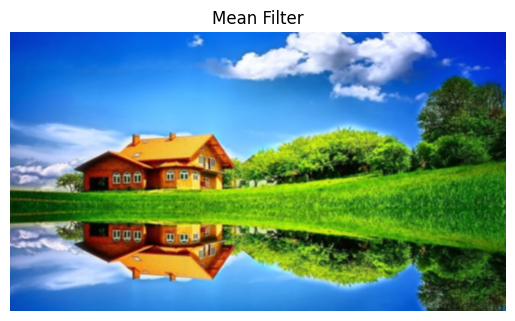

In [9]:
#Lọc trung bình: Làm mờ ảnh bằng cách tính giá trị trung bình của các điểm ảnh trong một vùng lân cận.
def mean_filter(image):
    return cv2.blur(image, (5,5))

mean = mean_filter(img)

plt.imshow(mean)
plt.title("Mean Filter")
plt.axis('off')

### II.2 Gaussian

(np.float64(-0.5), np.float64(1199.5), np.float64(674.5), np.float64(-0.5))

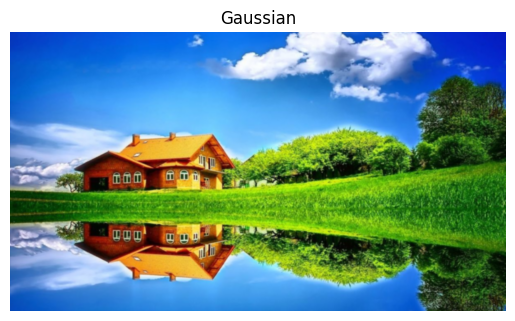

In [10]:
#Lọc Gaussian: Làm mờ ảnh bằng cách áp dụng một bộ lọc Gaussian, trong đó mỗi điểm ảnh được tính toán dựa trên một hàm Gaussian của các điểm ảnh lân cận.
def gaussian_filter(image):
    return cv2.GaussianBlur(image, (5,5), 0)

gauss = gaussian_filter(img)

plt.imshow(gauss)
plt.title("Gaussian")
plt.axis('off')

### II.3 Làm sắc nét

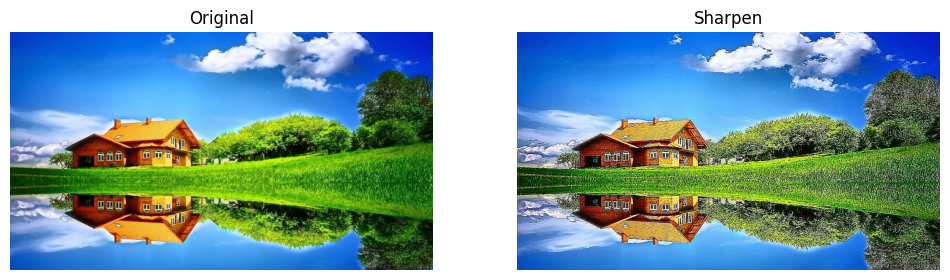

In [23]:
#Lọc sắc nét: Làm sắc nét ảnh bằng cách áp dụng một bộ lọc làm nổi bật các cạnh và chi tiết trong hình ảnh.
def sharpen(image):
    # Kernel mạnh hơn
    kernel = np.array([
        [-1,-1,-1],
        [-1, 9,-1],
        [-1,-1,-1]
    ])
    return cv2.filter2D(image, -1, kernel)

sharp = sharpen(img)

plt.figure(figsize=(12,5))
# Hiển thị song song
plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(sharp)
plt.title("Sharpen")
plt.axis('off')

plt.show()

## III. Nâng cao

### III.1 Sobel

(np.float64(-0.5), np.float64(1199.5), np.float64(674.5), np.float64(-0.5))

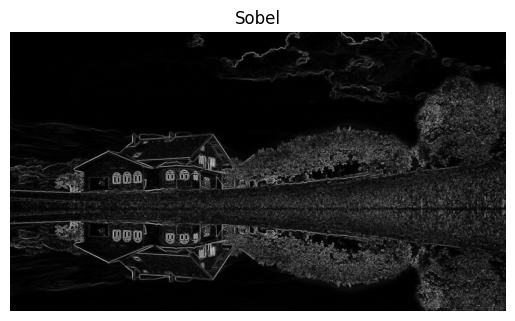

In [12]:
#Phát hiện cạnh bằng Sobel: Phát hiện các cạnh trong hình ảnh bằng cách sử dụng bộ lọc Sobel, trong đó mỗi điểm ảnh được tính toán dựa trên sự thay đổi cường độ của các điểm ảnh lân cận.
def sobel_edge(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    sx = cv2.Sobel(gray, cv2.CV_64F, 1, 0)
    sy = cv2.Sobel(gray, cv2.CV_64F, 0, 1)
    return np.sqrt(sx**2 + sy**2)

sobel = sobel_edge(img)

plt.imshow(sobel, cmap='gray')
plt.title("Sobel")
plt.axis('off')

### III.2 Prewitt

(np.float64(-0.5), np.float64(1199.5), np.float64(674.5), np.float64(-0.5))

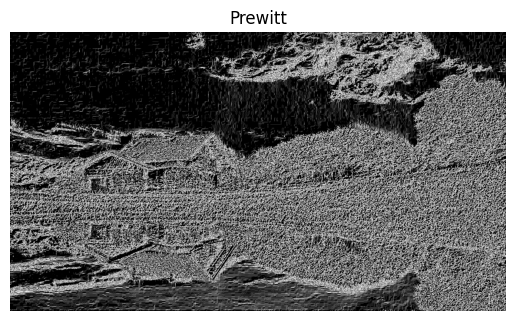

In [13]:
#Phát hiện cạnh bằng Prewitt: Phát hiện các cạnh trong hình ảnh bằng cách sử dụng bộ lọc Prewitt, trong đó mỗi điểm ảnh được tính toán dựa trên sự thay đổi cường độ của các điểm ảnh lân cận.
def prewitt_edge(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    kx = np.array([[1,0,-1],[1,0,-1],[1,0,-1]])
    ky = np.array([[1,1,1],[0,0,0],[-1,-1,-1]])
    x = cv2.filter2D(gray, -1, kx)
    y = cv2.filter2D(gray, -1, ky)
    return np.sqrt(x**2 + y**2)

prewitt = prewitt_edge(img)

plt.imshow(prewitt, cmap='gray')
plt.title("Prewitt")
plt.axis('off')

### III.3 Custom Kernel

(np.float64(-0.5), np.float64(1199.5), np.float64(674.5), np.float64(-0.5))

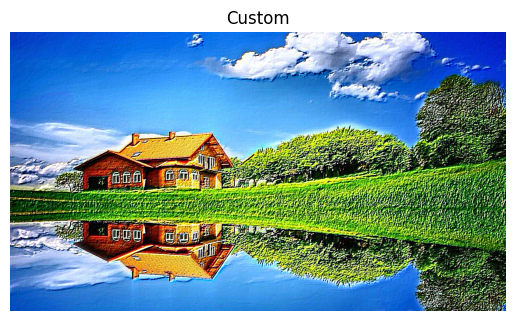

In [14]:
#Tạo bộ lọc tùy chỉnh: Tạo một bộ lọc tùy chỉnh bằng cách định nghĩa một ma trận và áp dụng nó cho hình ảnh bằng cách sử dụng phép toán tích chập.
def custom_kernel(image):
    kernel = np.array([[-2,-1,0],[-1,1,1],[0,1,2]])
    return cv2.filter2D(image, -1, kernel)

custom = custom_kernel(img)

plt.imshow(custom)
plt.title("Custom")
plt.axis('off')

### III.4 Median

(np.float64(-0.5), np.float64(1199.5), np.float64(674.5), np.float64(-0.5))

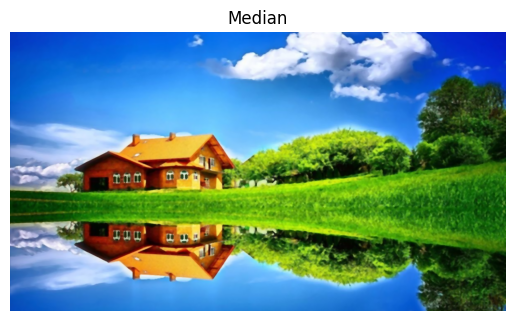

In [15]:
#Lọc trung vị: Làm mờ ảnh bằng cách thay thế mỗi điểm ảnh bằng giá trị trung vị của các điểm ảnh trong một vùng lân cận.
def median_filter(image):
    return cv2.medianBlur(image, 5)

median = median_filter(img)

plt.imshow(median)
plt.title("Median")
plt.axis('off')